# **🔬 Explicabilidad del Modelo**

Qué aprendió el modelo final (**LightGBM tuneado** con el conjunto `candidatas` y umbral 0,15) y por qué decide lo que decide. Se usan tres lentes complementarias:

1. **SHAP**: cuánto sube o baja cada variable el riesgo de cada transacción. Da la importancia global y explicaciones individuales.
2. **Forma de las relaciones**: dependencia SHAP (efecto por transacción) y dependencia parcial (predicción media al fijar una variable).
3. **Importancia por permutación medida en ganancia**: cuánto dinero se pierde si una variable se desordena, que es la lectura de negocio.

El modelo se entrena con 4 de los 5 folds nuevos del notebook 04 (semilla 7) y se explica sobre el quinto, **30.000 transacciones que no vio**. Es el mismo modelo del primer fold de la validación del 04.

**Advertencia de lectura**: SHAP y la permutación reparten el crédito entre variables correlacionadas. Como se vio en la exploración, `d`/`m`, `f`/`l` y `e`/`monto` hay que leerlos como pares.

## **📚 Librerías**

In [1]:
# Librerías para manipulación de datos
import os

import pandas as pd
import numpy as np

# Explicabilidad y lectura del modelo registrado en MLflow
import mlflow
import shap
import matplotlib.pyplot as plt

# Métrica de ranking
from sklearn.metrics import roc_auc_score

# Librerías de visualización
import plotly.express as px
import plotly.io as pio

# Módulos del proyecto: features, modelo, validación y ganancia
from fraude_shipping.experimentacion.modelos import crear_modelo
from fraude_shipping.experimentacion.validacion import agregar_tasas_fraude
from fraude_shipping.features import SEMILLA, cargar_datos, construir_features, crear_folds, preparar_categoricas
from fraude_shipping.ganancia import calcular_ganancia, metricas_decision
from fraude_shipping.produccion.pipeline import FEATURES_MODELO, PARAMETROS_LIGHTGBM, UMBRAL
from fraude_shipping.registro import configurar_mlflow

c:\Users\jmart\Documents\Proyectos\Data_Science\06_Proyectos\fraude_shipping\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Gráficos interactivos en el editor y PNG estático para GitHub y el informe
pio.renderers.default = 'plotly_mimetype+png'
pio.templates.default = 'plotly_white'

COLOR_PRINCIPAL = '#2a78d6'
COLOR_REFERENCIA = '#898781'
NOMBRE_EXPERIMENTO = 'fraude_shipping'
RUN_MODELO_FINAL = 'validacion_lightgbm_tuneado'
SEMILLA_VALIDACION = 7
PARAMETROS_ENTEROS = {'n_estimators', 'num_leaves', 'min_child_samples', 'subsample_freq'}

# SHAP tarda ~6 minutos sobre las 30.000 transacciones, así que se calcula sobre una muestra
TAMANO_MUESTRA_SHAP = 10000
TAMANO_MUESTRA_DEPENDENCIA = 3000
REPETICIONES_PERMUTACION = 5

## **🤖 Modelo final**

Si hay un servidor de MLflow configurado (`MLFLOW_TRACKING_URI` y sus credenciales), los parámetros, las features y el umbral se leen del run `validacion_lightgbm_tuneado` del notebook 04, así que el modelo explicado es exactamente el que se validó. Sin servidor, se toman de las constantes del pipeline productivo (`produccion/pipeline.py`), que tienen los mismos valores, y el notebook se puede ejecutar sin haber corrido antes el 04.

In [3]:
# Parámetros, features y umbral del LightGBM tuneado: del run de MLflow si hay servidor configurado, si no del pipeline productivo
if os.environ.get('MLFLOW_TRACKING_URI'):
    configurar_mlflow(NOMBRE_EXPERIMENTO)
    run = mlflow.search_runs(
        filter_string=f"attributes.run_name = '{RUN_MODELO_FINAL}'", order_by=['attributes.start_time DESC']
    ).iloc[0]

    parametros = {}
    for nombre, valor in run.items():
        parametro = nombre.removeprefix('params.')
        if nombre.startswith('params.') and parametro not in ('modelo', 'numero_features'):
            parametros[parametro] = int(valor) if parametro in PARAMETROS_ENTEROS else float(valor)

    definicion = mlflow.artifacts.load_dict(f"{run['artifact_uri']}/features.json")
    umbral = round(run['metrics.umbral'], 2)
    origen = f'run {RUN_MODELO_FINAL} de MLflow'
else:
    parametros = PARAMETROS_LIGHTGBM
    # La tasa de fraude de j no es una columna del dataset: se calcula dentro de cada fold a partir de j
    definicion = {'features': [columna for columna in FEATURES_MODELO if columna != 'j_tasa_fraude'], 'columnas_tasa': ['j']}
    umbral = UMBRAL
    origen = 'constantes de produccion/pipeline.py'

columnas_modelo = [*definicion['features'], *(f'{columna}_tasa_fraude' for columna in definicion['columnas_tasa'])]
print(f'Origen: {origen} | Umbral: {umbral} | Features: {len(columnas_modelo)}')
parametros

Umbral: 0.15 | Features: 20


{'min_child_samples': 262,
 'n_estimators': 481,
 'colsample_bytree': 0.9604079184475345,
 'learning_rate': 0.019385512410777697,
 'num_leaves': 172,
 'subsample_freq': 1,
 'reg_alpha': 1.608317898022548,
 'subsample': 0.9601477375704716,
 'reg_lambda': 3.025159385030446}

In [4]:
# Datos y partición: 4 folds para entrenar y el quinto para explicar; la tasa de j se calcula como en la validación
datos = construir_features(cargar_datos('../data/raw/dataset.csv'))
datos = preparar_categoricas(datos, [*definicion['features'], *definicion['columnas_tasa']])
indices_train, indices_explicacion = crear_folds(datos['fraude'], semilla=SEMILLA_VALIDACION)[0]
train, explicacion = agregar_tasas_fraude(
    datos.iloc[indices_train], datos.iloc[indices_explicacion], definicion['columnas_tasa']
)
print(f'Train: {len(train):,} | Explicación: {len(explicacion):,} ({explicacion["fraude"].sum()} fraudes)')

Train: 120,000 | Explicación: 30,000 (1500 fraudes)


In [5]:
# Entrenamiento y resultado sobre las transacciones no vistas, con el umbral del notebook 04
modelo = crear_modelo('lightgbm', columnas_modelo, parametros).fit(train[columnas_modelo], train['fraude'])
variables_explicacion = explicacion[columnas_modelo]
explicacion['probabilidad'] = modelo.predict_proba(variables_explicacion)[:, 1]
explicacion['aprobada'] = explicacion['probabilidad'] < umbral

pd.Series({
    'auc_roc': roc_auc_score(explicacion['fraude'], explicacion['probabilidad']),
    **metricas_decision(explicacion['fraude'], explicacion['monto'], explicacion['aprobada']),
}).round(3)

auc_roc                    0.892
ganancia_pct_maxima       77.946
aprobadas_pct             92.620
fraudes_detectados_pct    53.600
dtype: float64

**💡 Hallazgos**

- En el fold de explicación el modelo llega a un **AUC de 0,892** y al **77,9% de la ganancia máxima**: aprueba el 92,6% de las transacciones y detecta el 53,6% de los fraudes.
- Está ~1 punto por debajo de la media de la validación del notebook 04 (78,9% ± 1,4), dentro de la variación normal entre folds. Es un fold representativo para explicar el modelo.

## **🌍 Importancia global (SHAP)**

Los valores SHAP descomponen la predicción de cada transacción en aportes por variable: parten del riesgo promedio y cada variable **suma o resta** hasta llegar a la predicción final. Están en **log-odds** (la escala interna del modelo): un valor positivo empuja hacia fraude y uno negativo hacia legítima. La importancia global es el valor absoluto medio de esos aportes.

In [6]:
# Valores SHAP de una muestra estratificada del fold de explicación
muestra_shap = explicacion.groupby('fraude', group_keys=False).sample(
    frac=TAMANO_MUESTRA_SHAP / len(explicacion), random_state=SEMILLA
)
explicador = shap.TreeExplainer(modelo)
valores_shap = explicador(muestra_shap[columnas_modelo])
shap_por_variable = pd.DataFrame(valores_shap.values, columns=columnas_modelo, index=muestra_shap.index)

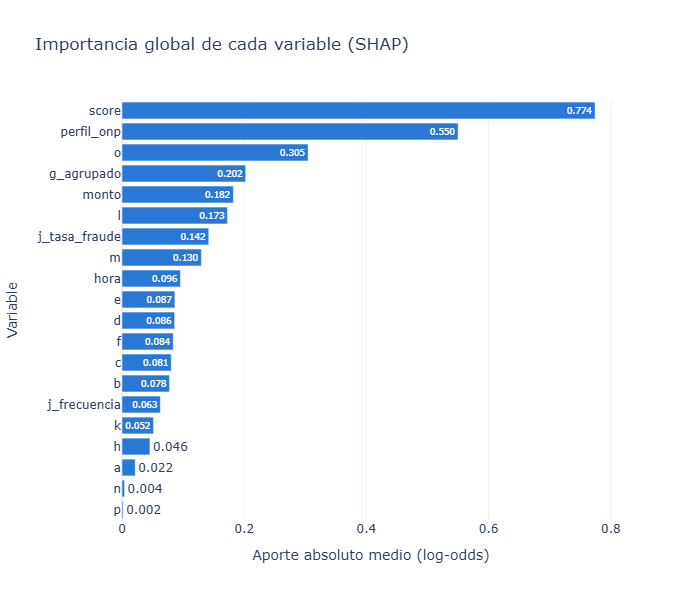

In [7]:
# Importancia global: aporte absoluto medio de cada variable
importancia_shap = shap_por_variable.abs().mean().sort_values()

fig = px.bar(
    importancia_shap,
    orientation='h',
    text_auto='.3f',
    color_discrete_sequence=[COLOR_PRINCIPAL],
    labels={'index': 'Variable', 'value': 'Aporte absoluto medio (log-odds)'},
    title='Importancia global de cada variable (SHAP)',
)
fig.update_layout(showlegend=False, height=600)
fig.show()

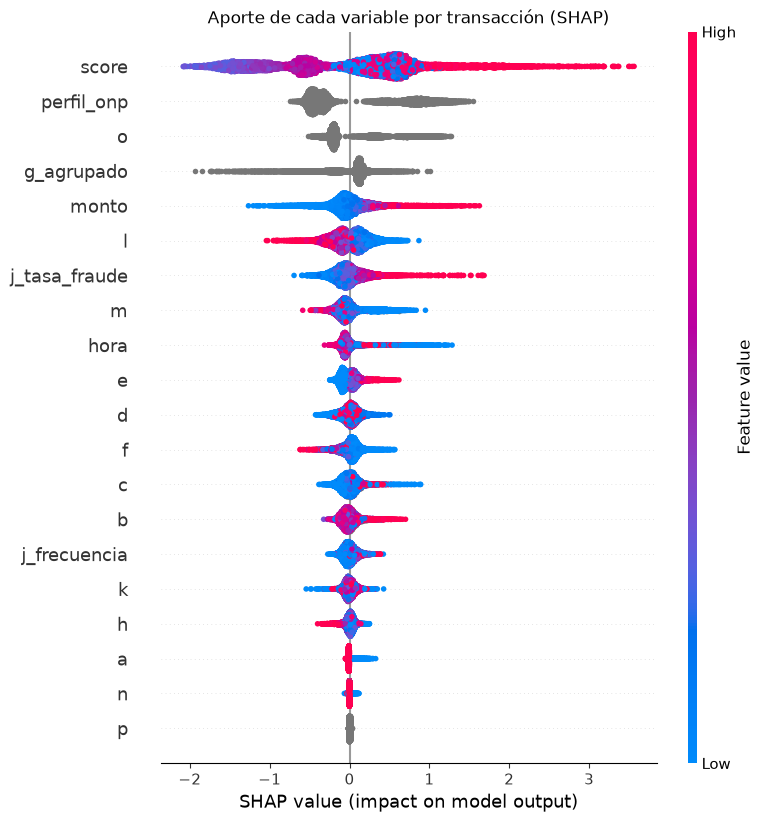

In [8]:
# Distribución de los aportes: cada punto es una transacción, coloreada por el valor de la variable (las categóricas en gris)
shap.plots.beeswarm(valores_shap, max_display=len(columnas_modelo), show=False)
plt.title('Aporte de cada variable por transacción (SHAP)')
plt.show()

**💡 Hallazgos**

- **`score` domina** (0,77 de aporte medio), seguido de **`perfil_onp` (0,55)** y **`o` (0,31)**: las tres variables con más señal individual en la exploración y en el ranking del notebook 03. `perfil_onp` contiene a `o`, así que conviene leerlas como un bloque (0,86 entre las dos).
- Después vienen `g_agrupado` (0,20), `monto` (0,18) y las variables de historial (`l`, `m`, `e`, `d`, `f`, entre 0,08 y 0,17), que hay que leer por pares (`d`/`m`, `f`/`l`, `e`/`monto`).
- `hora` queda novena (0,10) porque su efecto se concentra en la madrugada, con pocas transacciones: en el beeswarm se ve una cola de horas bajas (azul) con aportes de hasta +1,3.
- `a`, `n` y `p` casi no aportan (≤ 0,02): su información ya está en `perfil_onp`.
- El beeswarm confirma las direcciones de la exploración: `monto` alto sube el riesgo y `l` y `m` altos lo bajan. En `score`, en cambio, hay puntos azules (score bajo) con aporte positivo: la relación no es monótona.
- `k` recibe un aporte pequeño (0,05) aunque es ruido: el modelo corta en ella a veces, un sobreajuste leve sin impacto práctico.

## **📈 Forma de las relaciones**

Dos formas de ver cómo cambia el riesgo con una variable:

- **Dependencia SHAP**: el aporte de la variable en cada transacción según su valor. La dispersión vertical muestra cuánto depende ese aporte de las demás variables (interacciones).
- **Dependencia parcial**: la probabilidad media que predice el modelo si **todas** las transacciones tuvieran ese valor de la variable. Está en la escala de probabilidad, así que se compara directo con el umbral de 0,15.

Se analizan `score`, `hora` y `monto`, además de las categóricas `perfil_onp` y `o`.

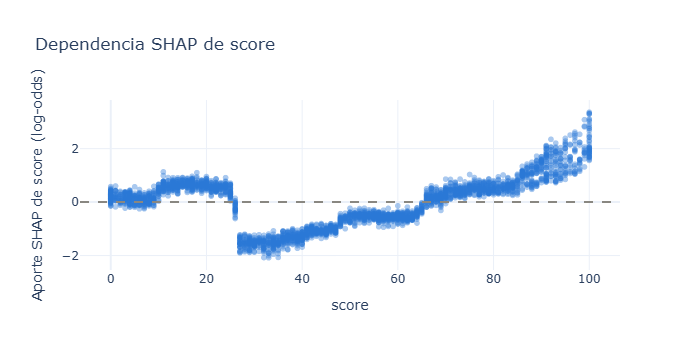

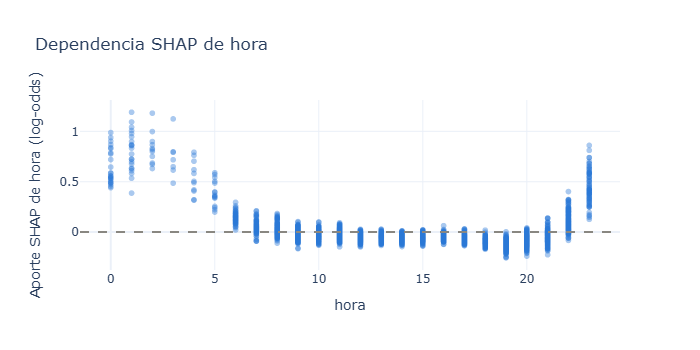

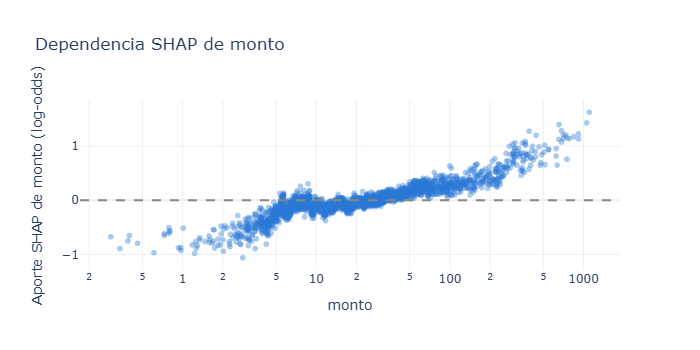

In [9]:
# Dependencia SHAP de las variables numéricas, sobre una submuestra para no embeber miles de puntos en el notebook
submuestra = shap_por_variable.sample(TAMANO_MUESTRA_DEPENDENCIA, random_state=SEMILLA).index

for columna, escala_log in [('score', False), ('hora', False), ('monto', True)]:
    fig = px.scatter(
        x=muestra_shap.loc[submuestra, columna],
        y=shap_por_variable.loc[submuestra, columna],
        opacity=0.4,
        log_x=escala_log,
        color_discrete_sequence=[COLOR_PRINCIPAL],
        labels={'x': columna, 'y': f'Aporte SHAP de {columna} (log-odds)'},
        title=f'Dependencia SHAP de {columna}',
    )
    fig.add_hline(y=0, line_dash='dash', line_color=COLOR_REFERENCIA)
    fig.update_layout(height=350)
    fig.show()

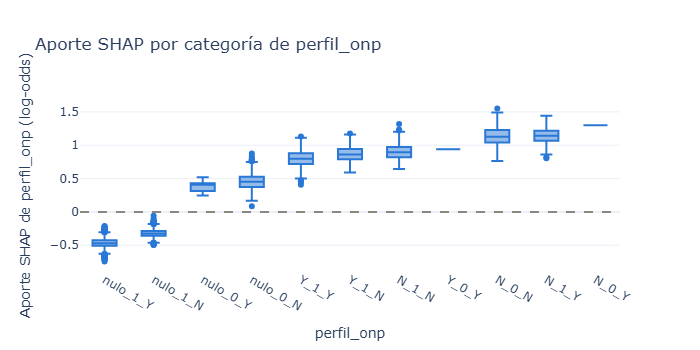

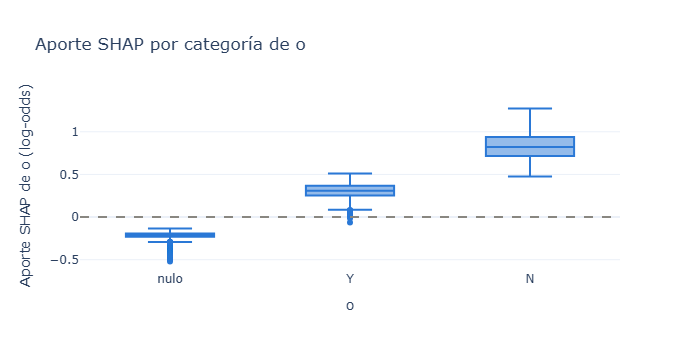

In [10]:
# Aporte SHAP por categoría de las variables categóricas, ordenadas por aporte medio
for columna in ['perfil_onp', 'o']:
    aportes = pd.DataFrame({
        'categoria': muestra_shap[columna].astype(str),
        'aporte': shap_por_variable[columna],
    })
    orden = aportes.groupby('categoria')['aporte'].mean().sort_values().index
    fig = px.box(
        aportes,
        x='categoria',
        y='aporte',
        category_orders={'categoria': list(orden)},
        color_discrete_sequence=[COLOR_PRINCIPAL],
        labels={'categoria': columna, 'aporte': f'Aporte SHAP de {columna} (log-odds)'},
        title=f'Aporte SHAP por categoría de {columna}',
    )
    fig.add_hline(y=0, line_dash='dash', line_color=COLOR_REFERENCIA)
    fig.update_layout(height=350)
    fig.show()

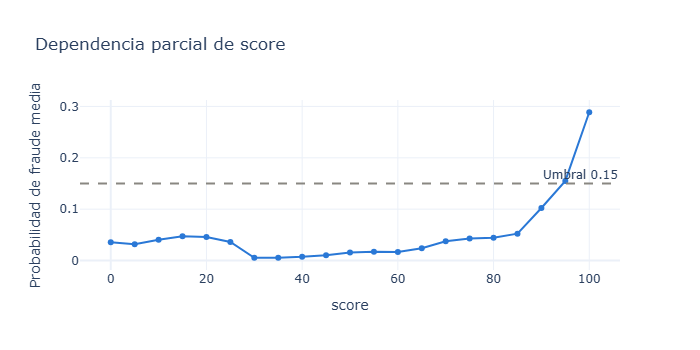

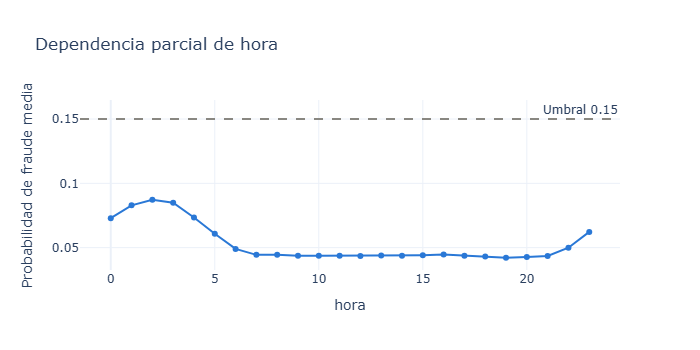

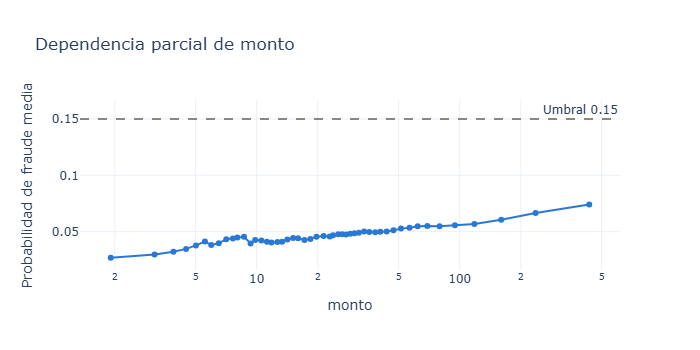

In [11]:
# Dependencia parcial: probabilidad media predicha al fijar cada variable en los valores de la grilla
def dependencia_parcial(modelo, variables, columna, grilla):
    """Probabilidad media predicha cuando todas las filas toman cada valor de la grilla en la columna indicada."""
    return pd.Series(
        [modelo.predict_proba(variables.assign(**{columna: valor}))[:, 1].mean() for valor in grilla],
        index=grilla,
    )


variables_dependencia = variables_explicacion.loc[submuestra]
grillas = {
    'score': np.arange(0, 101, 5),
    'hora': np.arange(24),
    'monto': np.unique(variables_explicacion['monto'].quantile(np.linspace(0.01, 0.99, 50)).round(2)),
}
for columna, grilla in grillas.items():
    curva = dependencia_parcial(modelo, variables_dependencia, columna, grilla)
    fig = px.line(
        x=curva.index,
        y=curva.to_numpy(),
        markers=True,
        log_x=columna == 'monto',
        color_discrete_sequence=[COLOR_PRINCIPAL],
        labels={'x': columna, 'y': 'Probabilidad de fraude media'},
        title=f'Dependencia parcial de {columna}',
    )
    fig.add_hline(y=umbral, line_dash='dash', line_color=COLOR_REFERENCIA, annotation_text=f'Umbral {umbral}')
    fig.update_layout(height=350)
    fig.show()

**💡 Hallazgos**

- **`score` reproduce la forma en U de la exploración**: su aporte SHAP es positivo entre 0 y 24 (+0,41), muy negativo entre 25 y 49 (−1,16) y crece desde 65 hasta +1,67 entre 90 y 100. En la dependencia parcial, la probabilidad media pasa de 3,6% con score 0 a 0,5% con 30–35, y sube a 15,5% con 95 y 28,9% con 100. **Solo con score ≥ 95 la variable por sí sola lleva la probabilidad media por encima del umbral.**
- **El modelo aprendió el riesgo de la madrugada sin necesidad de segmentar**: entre las 0 y las 4 el aporte de `hora` es de +0,72, y la probabilidad media sube a 7,3–8,7%, frente a 4,3–4,5% durante el día. Entre las 22 y las 23 también sube (+0,25). Entre las 7 y las 21 el aporte es prácticamente cero.
- **`monto` sube el riesgo de forma monótona**: de −0,23 por debajo de 10 a +0,86 por encima de 250. La probabilidad media pasa de 2,7% a 7,4% entre los montos más bajos y los más altos de la grilla.
- **`perfil_onp`**: `nulo_1_Y`, el perfil más frecuente (41% de la muestra), es el que más baja el riesgo (−0,47). Todos los perfiles con `o` informado suben el riesgo, y los más riesgosos son `N_0_N` y `N_1_Y` (+1,14). En `o` el orden es el de la exploración: nulo (−0,22), `Y` (+0,31) y `N` (+0,83).

## **💰 Importancia en ganancia (permutación)**

SHAP mide cuánto mueve cada variable la predicción, pero no cuánto dinero vale. La **importancia por permutación** desordena una variable a la vez en las 30.000 transacciones no vistas, vuelve a decidir con el umbral de 0,15 y mide **cuántos puntos de la ganancia máxima se pierden**. Para calcular la ganancia se usa siempre el monto real, aunque la variable desordenada sea `monto`. Cada variable se permuta 5 veces y se reporta la media y el desvío.

In [12]:
# Caída de la ganancia al desordenar cada variable, en puntos de % de la ganancia máxima
def perdida_por_permutacion(modelo, variables, fraude, monto, umbral, repeticiones, semilla):
    """Puntos de ganancia perdidos al permutar cada columna; la ganancia siempre se calcula con el monto real."""
    generador = np.random.default_rng(semilla)
    ganancia_maxima = calcular_ganancia(fraude, monto, fraude == 0)
    ganancia_base = calcular_ganancia(fraude, monto, modelo.predict_proba(variables)[:, 1] < umbral)
    filas = []
    for columna in variables.columns:
        for _ in range(repeticiones):
            permutadas = variables.copy()
            # Permutar con iloc conserva el dtype category que necesita LightGBM
            permutadas[columna] = variables[columna].iloc[generador.permutation(len(variables))].to_numpy()
            permutadas[columna] = permutadas[columna].astype(variables[columna].dtype)
            ganancia = calcular_ganancia(fraude, monto, modelo.predict_proba(permutadas)[:, 1] < umbral)
            filas.append({'variable': columna, 'perdida': (ganancia_base - ganancia) / ganancia_maxima * 100})
    return pd.DataFrame(filas).groupby('variable')['perdida'].agg(['mean', 'std']).sort_values('mean')


importancia_ganancia = perdida_por_permutacion(
    modelo, variables_explicacion, explicacion['fraude'], explicacion['monto'], umbral, REPETICIONES_PERMUTACION, SEMILLA
)
importancia_ganancia.round(3).iloc[::-1]

,mean,std
variable,,
score,7.527,1.213
g_agrupado,2.047,0.569
m,0.833,0.286
perfil_onp,0.656,0.776
o,0.520,0.314
monto,0.352,0.199
l,0.346,0.379
d,0.323,0.178
j_tasa_fraude,0.202,0.307


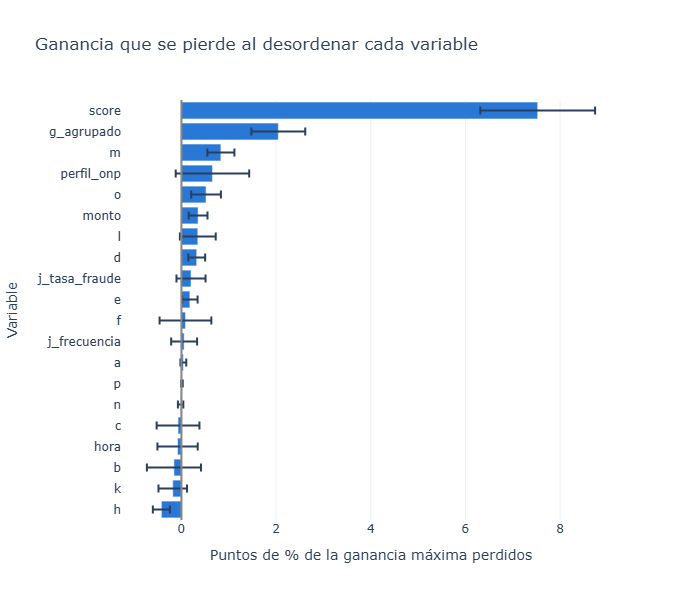

In [13]:
# Puntos de ganancia perdidos por variable, con su desvío entre repeticiones
fig = px.bar(
    importancia_ganancia.reset_index(),
    x='mean',
    y='variable',
    error_x='std',
    orientation='h',
    color_discrete_sequence=[COLOR_PRINCIPAL],
    labels={'mean': 'Puntos de % de la ganancia máxima perdidos', 'variable': 'Variable'},
    title='Ganancia que se pierde al desordenar cada variable',
)
fig.add_vline(x=0, line_color=COLOR_REFERENCIA)
fig.update_layout(height=600)
fig.show()

**💡 Hallazgos**

- **`score` es, lejos, la variable que más dinero vale**: desordenarla cuesta 7,5 puntos de la ganancia máxima (de ~78).
- **`g_agrupado` es la segunda en ganancia (2,0 puntos) aunque es cuarta en SHAP.** Pesa más en dinero que en ranking. Una hipótesis es que separa países con tasas de fraude y montos distintos: Uruguay (−1,18) y Estados Unidos (−0,56) son los que más bajan el riesgo en SHAP.
- `m` (0,83), `perfil_onp` (0,66), `o` (0,52), `monto` (0,35), `l` (0,35) y `d` (0,32) le siguen. `perfil_onp` y `o` pierden poco por separado porque se cubren entre sí: al desordenar una, la otra conserva casi toda la información.
- El desvío entre repeticiones va de 0,2 a 0,8 puntos, así que **solo `score`, `g_agrupado` y `m` superan con claridad el ruido**. El resto está cerca del límite.
- Varias variables dan **valores negativos**: desordenarlas mejora un poco la ganancia en este fold. El caso más claro es `h` (−0,42 ± 0,18), y también `k`, `b` y `hora`. Con un solo fold no alcanza para concluir que haya que quitarlas, pero indica que su aporte a la decisión es nulo o levemente negativo.
- `hora` es el mejor ejemplo de por qué conviene mirar las dos lentes: mueve la predicción en la madrugada (SHAP), pero no cambia la ganancia (permutación), porque afecta a pocas transacciones.

## **🔍 Explicaciones individuales**

Para mostrar cómo decide el modelo en casos concretos, se toma la transacción de **mayor monto** de cada tipo de resultado, porque son las que más pesan en la ganancia:

- **Fraude detectado**: fraude rechazado correctamente.
- **Fraude no detectado**: fraude aprobado, el error más caro.
- **Legítima rechazada**: una venta perdida.

Cada gráfico parte del riesgo promedio (abajo) y suma el aporte de cada variable hasta la predicción final (arriba), en log-odds.

In [14]:
# Transacción de mayor monto de cada tipo de resultado, con su explicación SHAP
casos = {
    'Fraude detectado': (explicacion['fraude'] == 1) & ~explicacion['aprobada'],
    'Fraude no detectado': (explicacion['fraude'] == 1) & explicacion['aprobada'],
    'Legítima rechazada': (explicacion['fraude'] == 0) & ~explicacion['aprobada'],
}
indices_casos = {nombre: explicacion.loc[filtro, 'monto'].idxmax() for nombre, filtro in casos.items()}
valores_casos = explicador(explicacion.loc[list(indices_casos.values()), columnas_modelo])

explicacion.loc[list(indices_casos.values()), ['monto', 'score', 'hora', 'perfil_onp', 'probabilidad']].assign(
    caso=list(indices_casos)
).set_index('caso').round(3)

,monto,score,hora,perfil_onp,probabilidad
caso,,,,,
Fraude detectado,1655.99,89,15,N_1_N,0.771
Fraude no detectado,1681.67,76,10,Y_1_Y,0.122
Legítima rechazada,2877.62,94,6,Y_1_N,0.240


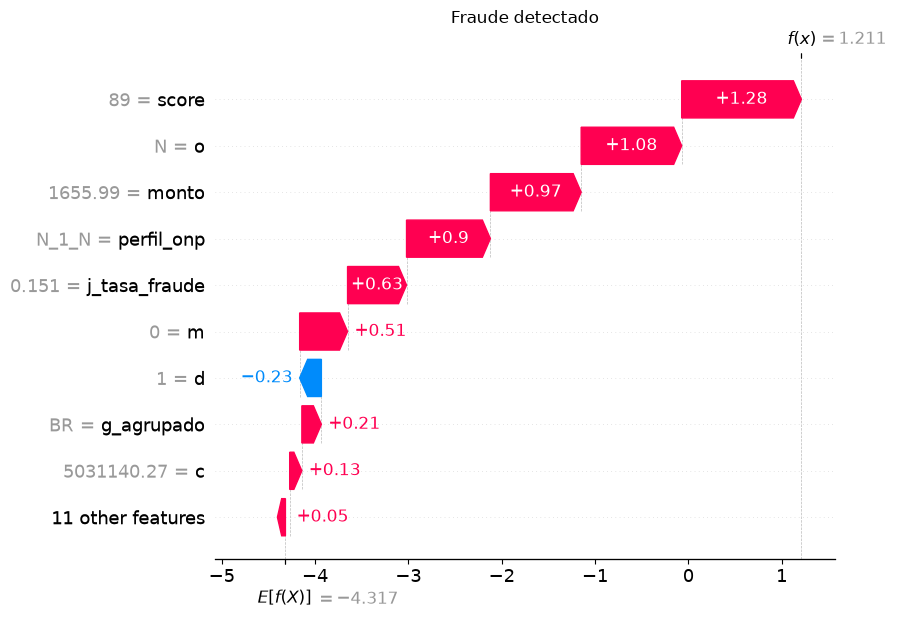

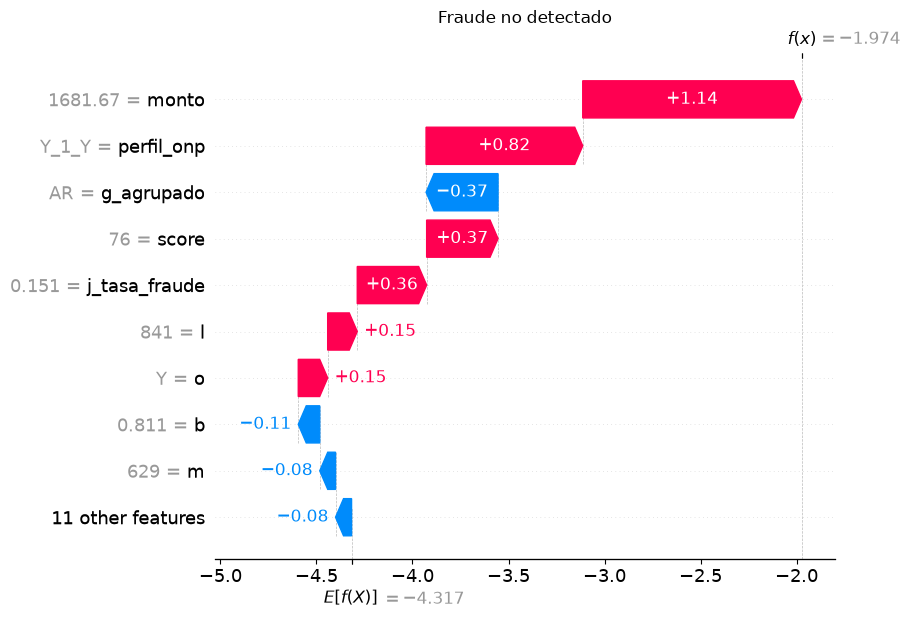

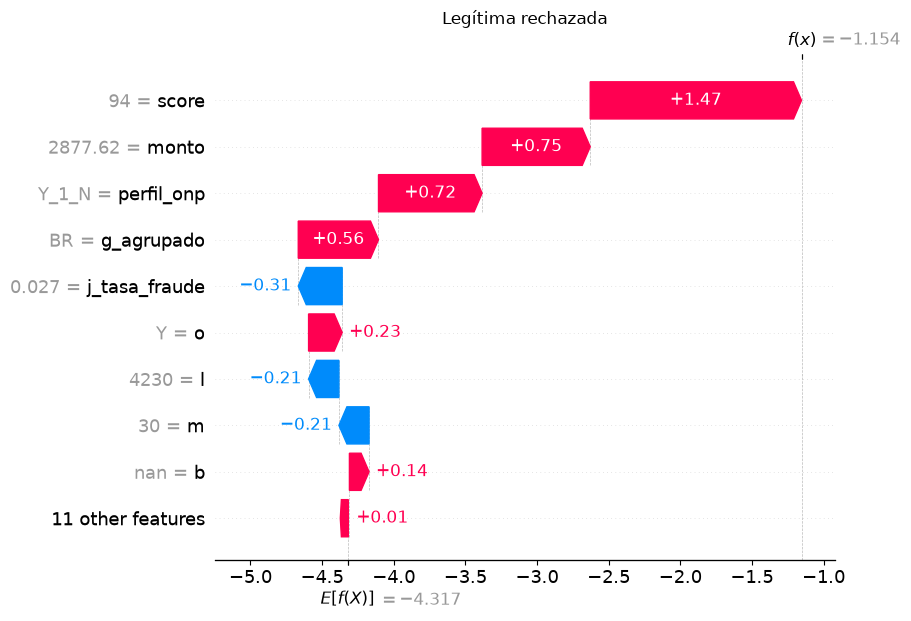

In [15]:
# Aporte de cada variable en los tres casos
for posicion, nombre in enumerate(indices_casos):
    shap.plots.waterfall(valores_casos[posicion], max_display=10, show=False)
    plt.title(nombre)
    plt.show()

**💡 Hallazgos**

El riesgo promedio de partida es de −4,32 en log-odds, y el umbral de 0,15 equivale a −1,73.

- **Fraude detectado** (monto 1.656, probabilidad 0,77): todas las señales principales apuntan al fraude a la vez. Suben el riesgo `score` 89 (+1,28), `o = N` (+1,08), el monto alto (+0,97), el perfil `N_1_N` (+0,90) y una categoría `j` riesgosa (+0,63).
- **Fraude no detectado** (monto 1.682, probabilidad 0,12): quedó **justo por debajo del umbral** (−1,97 frente a −1,73). El monto (+1,14) y el perfil `Y_1_Y` (+0,82) empujaban hacia el fraude, pero el `score` de 76 aportó poco (+0,37) y ser de Argentina restó (−0,37). Es un fraude sin la señal más fuerte del modelo.
- **Legítima rechazada** (monto 2.878, probabilidad 0,24): para el modelo tiene perfil de fraude: `score` 94 (+1,47), monto alto (+0,75), perfil `Y_1_N` (+0,72) y Brasil (+0,56). Solo la categoría `j` de bajo riesgo (−0,31) y un `l` alto (−0,21) la compensaban.
- Los dos errores caros tienen la misma raíz: **el modelo depende mucho de `score`**. Falla cuando un fraude tiene score medio o cuando una legítima tiene score muy alto.

## **🧭 Conclusiones**

- El modelo se apoya en **`score`, el bloque `perfil_onp`/`o`, `g_agrupado` y `monto`**, en ese orden, y aprendió relaciones coherentes con la exploración: la U de `score`, el riesgo de la madrugada, más riesgo con más monto y más riesgo con `o` informado.
- **`score` es la pieza crítica**: es lejos la variable más valiosa en ganancia (7,5 puntos) y la raíz de los errores más caros. El supuesto de que está disponible al momento de decidir es el más importante del modelo, aunque el baseline mostró que sin ella se pierden solo ~1,3 puntos.
- **Importar en SHAP no es lo mismo que importar en dinero**: `g_agrupado` vale más en ganancia que en ranking, y `hora` al revés. Para decisiones de negocio conviene la importancia por permutación en ganancia.
- `h`, `k`, `b` y `hora` no aportan a la ganancia en este fold. Si se quisiera simplificar el modelo, serían las primeras candidatas a quitar, validándolo con los 5 folds.
- Las variables correlacionadas (`d`/`m`, `f`/`l`, `e`/`monto` y `perfil_onp`/`o`) reparten su crédito, así que su importancia individual subestima la del par.